In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
from PIL import Image
from scipy.linalg import block_diag
import random
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers

# **Stochastic Gradient Descent**
In your favorite programming language, implement stochastic gradient descent for the linear least squares loss $f(\mathbf{w}) = \frac{1}{2} \|\mathbf{Aw}-\mathbf{b} \|_2^2$. Provide convergence plots to validate the convergence guarantees for SGD discussed in class. Specifically, compare empirical and theoretical convergence rates when $\mathbf{A}\in\R^{10000\times1000}$ has i.i.d. $\mathcal{N}(0,1/\sqrt{1000})$ Gaussian entries and $\mathbf{b}=\mathbf{A1}+\varepsilon$ where $\mathbf{1}$ is the all-ones vector and $\varepsilon$ has i.i.d. Gaussian entries with variance 1, then 0.1, then 0.01, and finally 0. Repeat the comparisons, but now consider $\mathbb{A}\in\R^{10000\times1000}$ whose $j$th row has i.i.d. $\mathcal{N}(0,1/\sqrt{1000j})$ Gaussian entries. (\textit{Note: your answer should include 8 plots, because there are two choices of $\mathbf{A}$} and four different choice of $\varepsilon$)

In [181]:
def SGD(A, n, m, mu_vareps, sigma_vareps, step_size, iterations):

    vareps = np.random.normal(loc=mu_vareps, scale=sigma_vareps, size=n)
    ones = np.ones(m)

    b = A @ ones + vareps
    w_star = np.linalg.pinv(A) @ b

    w = np.zeros(m)
    
    t = np.arange(iterations)
    W = np.zeros(iterations)
    for i in range (iterations):
        W[i] = np.linalg.norm(w - w_star)
        k = np.random.randint(0, n)
        a = A[k,:]
        l = A[k,:] @ w - b[k]
        gradf = (a * l)
        w = w - step_size*gradf
    return t, W 

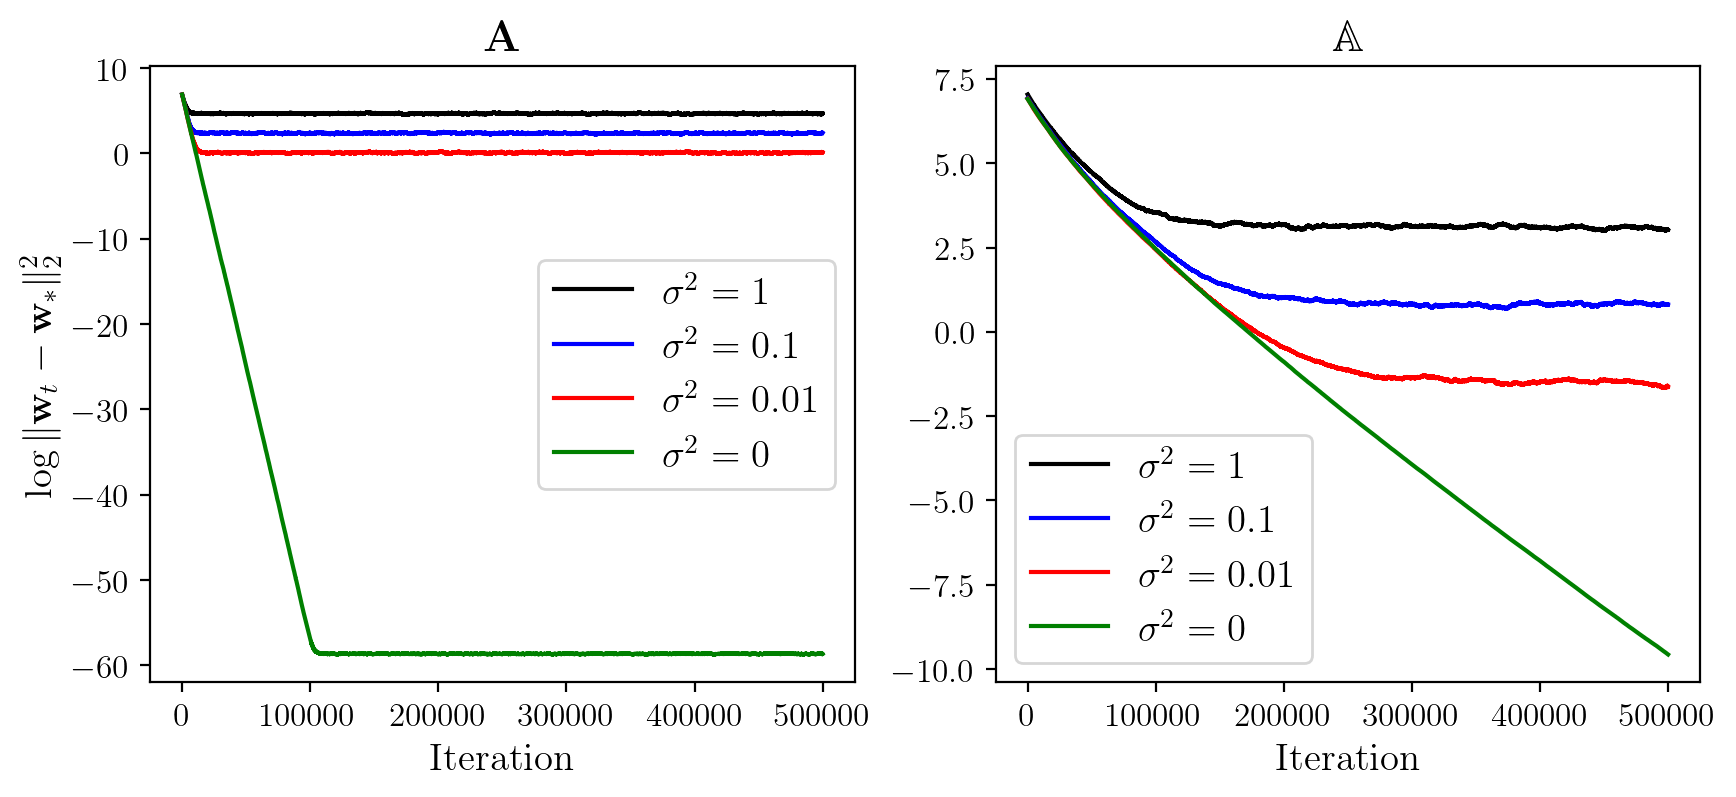

In [190]:
A = np.random.normal(loc=0, scale=1/1000**0.25, size=(10000, 1000))

mathbbA = np.random.normal(loc=0, scale=1, size=(10000, 1000))
j = np.arange(1,10001)
rootvar = 1/(1000*j)**0.25
D = np.diag(rootvar)
mathbbA = D @ mathbbA

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)  # 2 rows, 2 columns
fig.set_dpi(200)

niter = 500000
colors = ["black", "blue", "red", "green"]
variance = [1, 0.1, 0.01, 0]
step_size = 0.05

#handles = []
#labels = []

for i in range(len(variance)):
    t, W = SGD(A, A.shape[0], A.shape[1], 0, variance[i]**0.5, step_size, niter)
    
    axes[0].plot(t, np.log(W**2), label=rf"$\sigma^2={variance[i]}$", color = colors[i])
    axes[0].set_ylabel(r"$\log \|\mathbf{w}_t - \mathbf{w}_*\|^2_2$", fontsize=14)
    axes[0].legend(fontsize=14)
    axes[0].set_xlabel("Iteration", fontsize=14)
    axes[0].set_title(r"$\mathbf{A}$", fontsize=16)
    axes[0].tick_params(axis='both', labelsize=12)

    t, W = SGD(mathbbA, mathbbA.shape[0], mathbbA.shape[1], 0, variance[i]**0.5, step_size, niter)
    
    axes[1].plot(t, np.log(W**2), label=rf"$\sigma^2={variance[i]}$", color = colors[i])
    axes[1].legend(fontsize=14)
    axes[1].set_xlabel("Iteration", fontsize=14)
    axes[1].set_title(r"$\mathbb{A}$", fontsize=16)
    axes[1].tick_params(axis='both', labelsize=12)

# Put ALL entries in the top subplot legend
#axes[0].legend(handles, labels)
#axes[-1].set_xlabel("Iteration")